# SMOTE strategy: 

Create artifical data to balance target classes
we might get good evaluation metrics here, but we have to check the counterfactuals...

## load

In [14]:
import os
from pathlib import Path
import joblib

from dotenv import load_dotenv
import pandas as pd

In [15]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [16]:
train_df = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32883 entries, 0 to 32882
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   etfruit   32883 non-null  int64  
 1   eatveg    32883 non-null  int64  
 2   cgtsmok   32883 non-null  int64  
 3   alcfreq   32883 non-null  int64  
 4   slprl     32883 non-null  int64  
 5   paccnois  32883 non-null  int64  
 6   bmi       32883 non-null  float64
 7   dosprt    32883 non-null  int64  
 8   hltprhc   32883 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 2.3 MB


In [18]:
train_df.head(5)

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
0,3,3,6,5,1,0,21.453287,2,0
1,6,3,2,2,4,0,25.181077,7,0
2,4,1,3,2,2,0,23.529412,5,0
3,5,4,4,2,3,0,30.487805,2,0
4,4,4,2,2,2,0,26.769780,2,0


In [19]:
TARGET = "hltprhc"

X_train = train_df.drop(TARGET, axis=1)
y_train = train_df[TARGET]

X_test = test_df.drop(TARGET, axis=1)
y_test = test_df[TARGET]

print(X_train.shape)
print(X_test.shape)

(32883, 8)
(8221, 8)


### SMOTE

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [21]:
import matplotlib.pyplot as plt

def plot_target_distribution(y_before, y_after, label):
    fig, ax = plt.subplots(figsize=(8, 5))

    before_counts = y_before.value_counts().sort_index()
    after_counts = y_after.value_counts().sort_index()

    x = range(len(before_counts))
    width = 0.35

    ax.bar([i - width/2 for i in x], before_counts.values, width, label='Before', alpha=0.8)
    ax.bar([i + width/2 for i in x], after_counts.values, width, label='After', alpha=0.8)

    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}")
    ax.set_xticks(x)
    ax.set_xticklabels(before_counts.index)
    ax.legend()

    plt.tight_layout()
    plt.show()


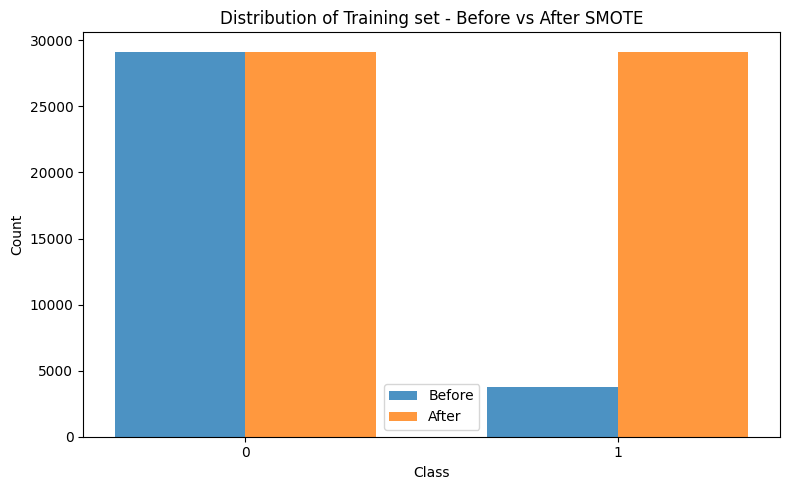

In [22]:
plot_target_distribution(y_train, y_train_res, label="Training set - Before vs After SMOTE")

### Train with SMOTE inside Gridsearch Pipeline

this is to prevent leakage, scikit will handle SMOTE

In [23]:
from imblearn.pipeline import Pipeline # Use Imblearns pipeline!
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

In [ ]:
# first with 400 iterations
# cv5
first_param_dist = {
    "xgb__n_estimators": randint(200, 1200),
    # More boosting rounds. Needed if learning_rate is small.

    "xgb__max_depth": randint(3, 15),
    # Allow deeper trees. Can capture more complex interactions.

    "xgb__learning_rate": uniform(0.005, 0.3),
    # Wider range. Very small LR + many trees can improve recall.

    "xgb__subsample": uniform(0.3, 0.7),
    # Allow more randomness. Helps generalization.

    "xgb__colsample_bytree": uniform(0.3, 0.7),
    # Same here. Lower values often help with noisy tabular data.

    "xgb__min_child_weight": randint(1, 15),
    # Larger range. Higher values prevent overfitting.

    "xgb__gamma": uniform(0, 5),
    # Much wider. Stronger split regularization can help stability.

    "xgb__reg_lambda": uniform(0, 10),
    # Stronger L2 regularization. Helps noisy datasets.

    "xgb__reg_alpha": uniform(0, 10),
    # Stronger L1 regularization. Can simplify trees.

    "xgb__scale_pos_weight": [None], # NO WEIGHTS!
}

In [51]:
# Run 002: Refined based on Run 001 analysis
# Key findings from Run 001 (top 20 models, mean_test_score 0.534-0.540):
# - Learning rates: 0.012-0.284 (WIDE range! Low LR performs well with more trees)
# - Subsample: 0.446-0.957 (full range effective, not just high)
# - Colsample_bytree: 0.529-0.988 (varied, moderate to high retention)
# - Max_depth: 9-14 (deeper trees perform better than expected)
# - n_estimators: 203-1151 (varied, but 600+ common in top performers)
# - min_child_weight: 1-12 (varied, no clear pattern)
# - gamma: 0.416-4.84 (varied, moderate regularization works)
# - reg_lambda: 0.288-9.751 (L2 regularization highly varied)
# - reg_alpha: 0.002-6.725 (L1 regularization highly varied)

param_dist_refined = {
    "xgb__n_estimators": randint(400, 1200),
    # Keep wide range 400-1200. Top performers often use 600+

    "xgb__max_depth": randint(9, 15),
    # CORRECTED: Data shows 9-14 performs better (deeper than expected!)

    "xgb__learning_rate": uniform(0.01, 0.27),  # 0.01-0.28
    # WIDE range! Low LR (0.01-0.05) works well with more trees

    "xgb__subsample": uniform(0.4, 0.6),  # 0.40-1.0
    # Full range effective, explore 0.4-1.0

    "xgb__colsample_bytree": uniform(0.5, 0.5),  # 0.50-1.0
    # Moderate to high retention (0.5-1.0) performs well

    "xgb__min_child_weight": randint(1, 13),
    # Keep full range 1-12, no clear winner

    "xgb__gamma": uniform(0.4, 4.6),  # 0.4-5.0
    # Moderate to strong regularization (0.4-5.0)

    "xgb__reg_lambda": uniform(0.3, 9.7),  # 0.3-10.0
    # L2 regularization highly varied, explore full range

    "xgb__reg_alpha": uniform(0, 7),  # 0.0-7.0
    # L1 regularization varied, some benefit from higher values

    "xgb__scale_pos_weight": [None],
    # Keep None - using SMOTE for balancing instead
}

In [52]:
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier())
])

rand = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist_refined,
    n_iter=400,
    scoring="f1_macro",
    n_jobs=-1,
    cv=5,
    verbose=2,
    random_state=42,
)
rand.fit(X_train, y_train)


print("RandomizedSearch Done. best score (cv):", rand.best_score_)
print("Best parameters:")
print(rand.best_params_)



Fitting 5 folds for each of 400 candidates, totalling 2000 fits
[CV] END xgb__colsample_bytree=0.6668543055695109, xgb__gamma=1.0571873624409276, xgb__learning_rate=0.1857398876961903, xgb__max_depth=13, xgb__min_child_weight=2, xgb__n_estimators=743, xgb__reg_alpha=5.827098485602952, xgb__reg_lambda=2.3596893735792785, xgb__scale_pos_weight=None, xgb__subsample=0.5090949803242604; total time=   2.6s
[CV] END xgb__colsample_bytree=0.6872700594236812, xgb__gamma=4.773285809485614, xgb__learning_rate=0.2076383642890794, xgb__max_depth=13, xgb__min_child_weight=5, xgb__n_estimators=1014, xgb__reg_alpha=3.120829269975138, xgb__reg_lambda=1.2697566834346279, xgb__scale_pos_weight=None, xgb__subsample=0.6755493351795203; total time=   2.7s
[CV] END xgb__colsample_bytree=0.6872700594236812, xgb__gamma=4.773285809485614, xgb__learning_rate=0.2076383642890794, xgb__max_depth=13, xgb__min_child_weight=5, xgb__n_estimators=1014, xgb__reg_alpha=3.120829269975138, xgb__reg_lambda=1.2697566834346279

In [53]:
res = pd.DataFrame(rand.cv_results_)

top_estimators = (
    res
    .sort_values("mean_test_score", ascending=False)
    .head(20)
)

top_estimators = top_estimators.drop(columns=[c for c in top_estimators.columns if c.startswith("param_")])
params = top_estimators["params"].apply(pd.Series)

top_estimators = pd.concat([top_estimators.drop(columns=["params"]), params], axis=1)

top_estimators.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,...,xgb__colsample_bytree,xgb__gamma,xgb__learning_rate,xgb__max_depth,xgb__min_child_weight,xgb__n_estimators,xgb__reg_alpha,xgb__reg_lambda,xgb__scale_pos_weight,xgb__subsample
152,1.776775,0.099091,0.195326,0.020524,0.535628,0.543487,0.549005,0.545944,0.519643,0.538741,...,0.846841,1.415540,0.032243,14.0,4.0,421.0,0.919346,8.720127,NaN,0.977942
210,2.648034,0.110640,0.237913,0.021653,0.535080,0.538850,0.550195,0.542436,0.525590,0.538430,...,0.895015,1.801524,0.031848,13.0,3.0,977.0,1.076538,2.469060,NaN,0.974394
156,3.911842,0.212866,0.354905,0.039154,0.532993,0.546405,0.545471,0.540490,0.524336,0.537939,...,0.813110,1.003726,0.018782,12.0,10.0,957.0,3.234681,0.311949,NaN,0.758996
197,2.835232,0.096483,0.213745,0.015840,0.533803,0.545448,0.543056,0.543556,0.523470,0.537867,...,0.931399,1.397003,0.035843,13.0,3.0,854.0,3.826882,2.549887,NaN,0.634544
204,1.630283,0.056928,0.088735,0.008956,0.532517,0.542181,0.547471,0.541975,0.523574,0.537544,...,0.767914,0.844712,0.131600,12.0,1.0,799.0,4.654382,8.015865,NaN,0.956307


In [54]:
top_estimators.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'xgb__colsample_bytree',
       'xgb__gamma', 'xgb__learning_rate', 'xgb__max_depth',
       'xgb__min_child_weight', 'xgb__n_estimators', 'xgb__reg_alpha',
       'xgb__reg_lambda', 'xgb__scale_pos_weight', 'xgb__subsample'],
      dtype='object')

In [55]:
desired_order = [
    # "run_id",
    "mean_fit_time", "std_fit_time",
    "mean_score_time", "std_score_time",
    "split0_test_score", "split1_test_score", "split2_test_score",
    "split3_test_score", "split4_test_score",
    "mean_test_score", "std_test_score", "rank_test_score",


    # None - no wieghting here - set first...
    "xgb__scale_pos_weight",


    # "set vars"
    "xgb__colsample_bytree",
    "xgb__gamma",
    "xgb__learning_rate",
    "xgb__max_depth",
    "xgb__min_child_weight",
    "xgb__n_estimators",
    "xgb__reg_alpha",
    "xgb__reg_lambda",
    "xgb__subsample",
]

top_estimators = top_estimators[desired_order]
top_estimators


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,...,xgb__scale_pos_weight,xgb__colsample_bytree,xgb__gamma,xgb__learning_rate,xgb__max_depth,xgb__min_child_weight,xgb__n_estimators,xgb__reg_alpha,xgb__reg_lambda,xgb__subsample
152,1.776775,0.099091,0.195326,0.020524,0.535628,0.543487,0.549005,0.545944,0.519643,0.538741,...,NaN,0.846841,1.415540,0.032243,14.0,4.0,421.0,0.919346,8.720127,0.977942
210,2.648034,0.110640,0.237913,0.021653,0.535080,0.538850,0.550195,0.542436,0.525590,0.538430,...,NaN,0.895015,1.801524,0.031848,13.0,3.0,977.0,1.076538,2.469060,0.974394
156,3.911842,0.212866,0.354905,0.039154,0.532993,0.546405,0.545471,0.540490,0.524336,0.537939,...,NaN,0.813110,1.003726,0.018782,12.0,10.0,957.0,3.234681,0.311949,0.758996
197,2.835232,0.096483,0.213745,0.015840,0.533803,0.545448,0.543056,0.543556,0.523470,0.537867,...,NaN,0.931399,1.397003,0.035843,13.0,3.0,854.0,3.826882,2.549887,0.634544
204,1.630283,0.056928,0.088735,0.008956,0.532517,0.542181,0.547471,0.541975,0.523574,0.537544,...,NaN,0.767914,0.844712,0.131600,12.0,1.0,799.0,4.654382,8.015865,0.956307
221,1.792001,0.059755,0.091067,0.007222,0.531634,0.545268,0.547146,0.542174,0.521204,0.537485,...,NaN,0.823045,2.696936,0.081825,13.0,10.0,909.0,1.050341,3.449356,0.842414
21,2.198254,0.217958,0.136400,0.016600,0.533348,0.541385,0.544944,0.543650,0.522812,0.537228,...,NaN,0.917651,1.875588,0.060360,13.0,3.0,1059.0,2.281712,2.436338,0.826690
214,6.261817,0.319875,0.528845,0.034648,0.537149,0.542463,0.541241,0.542045,0.521469,0.536873,...,NaN,0.925724,0.401530,0.014776,10.0,12.0,1062.0,1.064174,0.895091,0.868457
230,1.636023,0.052254,0.061912,0.003564,0.537836,0.540021,0.540335,0.541706,0.521892,0.536358,...,NaN,0.800941,3.079144,0.211980,12.0,2.0,922.0,0.306149,1.374837,0.759119
256,1.814042,0.066672,0.128182,0.005562,0.534671,0.536203,0.547580,0.542695,0.520166,0.536263,...,NaN,0.860004,2.322754,0.033987,14.0,7.0,688.0,3.663736,1.413258,0.916084


In [56]:
def append_run(df_new:pd.DataFrame, csv_path):
    """
    Appends a new run to a CSV file, automatically generating an incrementing run_id.
    Ensures run_id is the first column.
    """

    # Determine next run_id
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        next_id = df_existing["run_id"].max() + 1 if "run_id" in df_existing else 1
    else:
        next_id = 1

    # Assign run_id
    df_new["run_id"] = str(next_id).zfill(3)

    # round the decimals
    df_new = df_new.round(3)

    # Move run_id to the first column
    cols = ["run_id"] + [c for c in df_new.columns if c != "run_id"]
    df_new = df_new[cols]

    # Append or create file
    df_new.to_csv(
        csv_path,
        mode="a" if os.path.exists(csv_path) else "w",
        header=not os.path.exists(csv_path),
        index=False
    )


In [57]:
csv_grid_path = "xgb_gridsearch_runs.csv"

append_run(top_estimators, csv_grid_path)

### investigate run metrics

In [58]:
best_rf = rand.best_estimator_
best_rf_pred = best_rf.predict(X_test)

In [59]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


print(classification_report(y_test, best_rf_pred))
print()
print("Roc Score auc score: ", roc_auc_score(y_test, best_rf_pred), "\n")

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      7287
           1       0.19      0.47      0.27       934

    accuracy                           0.71      8221
   macro avg       0.55      0.61      0.55      8221
weighted avg       0.83      0.71      0.76      8221


Roc Score auc score:  0.6083196029184589 

